# Setup

## Set up notebook environment by importing libraries, defining centralized preprocessing configuration, and building the list of EMG data files to load.

In [ ]:
from __future__ import annotations

import os
import json
import math
import re
from pathlib import Path
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


@dataclass
class PreprocessingConfig:
    """
    Stores preprocessing and windowing settings for the new Mindrove CSV files.
    """

    # 200 samples at 500 Hz = 0.40 seconds of EMG history per prediction.
    window_size: int = 200

    # 25 samples at 500 Hz = one training window every 0.05 seconds.
    step_size: int = 25

    # Mindrove armband sampling rate.
    sample_rate_hz: int = 500

    # Ignore labeled segments that are too short to be useful.
    min_segment_seconds: float = 0.75

    # Optional safety filter: remove non-Rest windows whose centered RMS energy is too close to Rest.
    gesture_energy_multiplier: float = 1.10
    use_gesture_energy_filter: bool = False

# Create a config instance with default values.
cfg = PreprocessingConfig()

# Minimum number of samples for a valid labeled segment, based on the config settings.
min_segment_samples = int(cfg.min_segment_seconds * cfg.sample_rate_hz)

# Root directory path
root_dir = Path("/workspace/EMGTuner-master/mindrove_data")

# Find all CSV files in the directory and subdirectories, sorted for consistency.
# First 60 files are mixed unknown-subject files.
FIRST_MIXED_FILE_COUNT = 60

# After the first 60 files, every consecutive 5 files is one subject.
KNOWN_SUBJECT_BLOCK_SIZE = 5

MIXED_FIRST_60_SUBJECT_ID = "mixed_first_60_unknown_subjects"


def natural_time_sort_key(path: Path):
    """
    Sort filenames naturally so file names containing time are ordered correctly.
    """
    parts = re.split(r"(\d+)", path.name)

    key = []
    for part in parts:
        if part.isdigit():
            key.append((0, int(part)))
        else:
            key.append((1, part.lower()))

    return key


# Find all CSV files and sort them by the time/order encoded in the file name.
DATA_FILES = sorted(root_dir.rglob("*.csv"), key=natural_time_sort_key)

print("Number of CSV files found:", len(DATA_FILES))
print("First 10 files in sorted order:")
for i, f in enumerate(DATA_FILES[:10], start=1):
    print(i, f.name)

print("\nFiles around the first-60 boundary:")
for i, f in enumerate(DATA_FILES[55:70], start=56):
    print(i, f.name)

# Label mapping for the new Mindrove row-level labels in the last CSV column.
SPEC_LABEL_MAP = {
    "Extend": 0,
    "Fist": 1,
    "Flex": 2,
    "Pro": 3,
    "Radial": 4,
    "Rest": 5,
    "Sup": 6,
    "Ulnar": 7,
}
SPEC_INDEX_TO_LABEL = {v: k for k, v in SPEC_LABEL_MAP.items()}

# Print summary of the dataset and config settings.
print("Number of CSV files found:", len(DATA_FILES))
if len(DATA_FILES) > 0:
    print("Example file:", DATA_FILES[0])

print("Sample rate:", cfg.sample_rate_hz, "Hz")
print("Window size:", cfg.window_size, "samples =", cfg.window_size / cfg.sample_rate_hz, "seconds")
print("Step size:", cfg.step_size, "samples =", cfg.step_size / cfg.sample_rate_hz, "seconds")

Number of CSV files found: 130
First 10 files in sorted order:
1 2026-05-19T18-34-39.720895.csv
2 2026-05-19T18-38-49.273177.csv
3 2026-05-19T18-40-57.288124.csv
4 2026-05-19T18-42-12.569221.csv
5 2026-05-19T18-44-05.097153.csv
6 2026-05-19T18-58-16.574574.csv
7 2026-05-19T19-00-15.250665.csv
8 2026-05-19T19-06-04.828947.csv
9 2026-05-19T19-07-08.992604.csv
10 2026-05-19T19-09-10.110356.csv

Files around the first-60 boundary:
56 2026-05-21T02-47-30.606422.csv
57 2026-05-21T02-48-21.223863.csv
58 2026-05-21T02-49-12.435236.csv
59 2026-05-21T02-50-03.116990.csv
60 2026-05-21T02-50-58.864146.csv
61 2026-05-26T22-57-46.736789.csv
62 2026-05-26T22-58-40.143382.csv
63 2026-05-26T22-59-34.473499.csv
64 2026-05-26T23-01-02.102551.csv
65 2026-05-26T23-01-53.990804.csv
66 2026-05-26T23-03-53.750172.csv
67 2026-05-26T23-05-51.770163.csv
68 2026-05-26T23-08-56.926114.csv
69 2026-05-26T23-09-50.289141.csv
70 2026-05-26T23-10-43.074323.csv
Number of CSV files found: 130
Example file: /workspace/EMG

# Load Files

## Load all EMG files into Pandas DataFrames, standarize column names, and concatenate them into one single dataset.

In [94]:
def load_mindrove_file(path: str | Path) -> pd.DataFrame:
    """
    Load one Mindrove CSV file.
    """
    path = Path(path)
    
    # Read the CSV file, treating various forms of "NaN" as missing values.
    df = pd.read_csv(
        path,
        header=None,
        sep=r"\s+",
        engine="python",
        na_values=["nan", "NaN", "NULL", "None", ""]
    )

    # Drop rows that are completely empty (all NaN) and reset the index.
    df = df.dropna(how="all").reset_index(drop=True)

    # Validate that there are at least 2 columns (at least one channel + one label).
    if df.shape[1] < 2:
        raise ValueError(f"{path} must contain at least one channel column and one label column.")

    # Dynamically name the columns: Channel1, Channel2, ..., label_value.
    num_channels = df.shape[1] - 1
    channel_cols = [f"Channel{i + 1}" for i in range(num_channels)]
    label_col = "label_value"
    
    # Build the full list of column names and assign to the DataFrame.
    df.columns = channel_cols + [label_col]

    # Convert all channel and label columns to numeric, coercing errors to NaN.
    for col in channel_cols + [label_col]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Check for any rows where channel columns are NaN (which would indicate missing or non-numeric data).
    bad_channel_rows = df[channel_cols].isna().any(axis=1).sum()
    if bad_channel_rows > 0:
        raise ValueError(
            f"{path} has {bad_channel_rows} rows with missing/non-numeric channel values. "
            "The label column may be NaN, but channel columns should not be NaN."
        )

    return df


def label_value_to_name(value) -> object:
    """
    Convert numeric labels such as 0.0, 1.0, ..., 7.0 into class names.
    """
    if pd.isna(value):
        return np.nan

    # Convert to float first to handle cases where the label might be read as a string or a float.
    value_float = float(value)
    label_id = int(value_float) if value_float.is_integer() else value_float

    # Map the label ID to a name using the SPEC_INDEX_TO_LABEL dictionary
    return SPEC_INDEX_TO_LABEL.get(label_id, f"Label_{label_id}")


def infer_subject_from_file_order(file_order_zero_based: int) -> tuple[str, int, bool]:
    """
    Assign subject IDs based on the known dataset layout.

    Files 1-60:
        Mixed unknown subjects. These cannot be safely assigned to individual subjects.

    Files 61+:
        Every consecutive 5 files is one subject.
        61-65 -> known_subject_001
        66-70 -> known_subject_002
        71-75 -> known_subject_003
        etc.
    """
    if file_order_zero_based < FIRST_MIXED_FILE_COUNT:
        return (
            MIXED_FIRST_60_SUBJECT_ID,
            file_order_zero_based + 1,
            True
        )

    known_offset = file_order_zero_based - FIRST_MIXED_FILE_COUNT

    subject_num = known_offset // KNOWN_SUBJECT_BLOCK_SIZE + 1
    file_num_within_subject = known_offset % KNOWN_SUBJECT_BLOCK_SIZE + 1

    subject_id = f"known_subject_{subject_num:03d}"

    return subject_id, file_num_within_subject, False


def infer_channel_cols(df: pd.DataFrame) -> list[str]:
    """
    Dynamically find channel columns named Channel1, Channel2, ...
    """

    # Use a regex to find columns that match the pattern "Channel" followed by a number.
    channel_cols = [col for col in df.columns if re.fullmatch(r"Channel\d+", str(col))]

    # Sort the channel columns in numerical order based on the number in their name.
    def sort_key(name: str):
        m = re.search(r"(\d+)$", name)
        return int(m.group(1)) if m else float("inf")

    return sorted(channel_cols, key=sort_key)

all_dfs = []
schemas = []

# Process each file and build a combined DataFrame and a schema summary.
for file_order_zero_based, file in enumerate(DATA_FILES):
    # Load the file and infer channel columns.
    df = load_mindrove_file(file)
    file_channel_cols = infer_channel_cols(df)

    # Create a "label" column with human-readable class names based on the numeric "label_value" column.
    subject_id, subject_file_number, is_mixed_first_60 = infer_subject_from_file_order(
        file_order_zero_based
    )

    df["label"] = df["label_value"].apply(label_value_to_name)
    df["source_file"] = str(file)
    df["file_order"] = file_order_zero_based + 1
    df["subject_id"] = subject_id
    df["subject_file_number"] = subject_file_number
    df["is_mixed_first_60"] = is_mixed_first_60
    df["source_index"] = np.arange(len(df), dtype=np.int64)
    df["time_seconds"] = df["source_index"] / cfg.sample_rate_hz

    # Keep only the relevant columns for later processing and modeling.
    df = df[
        [
            "source_file",
            "file_order",
            "subject_id",
            "subject_file_number",
            "is_mixed_first_60",
            "source_index",
            "time_seconds",
        ]
        + file_channel_cols
        + ["label_value", "label"]
    ].copy()

    # Append the processed DataFrame to the list for later concatenation.
    all_dfs.append(df)

    # Append a summary of the file's schema and label distribution to the schemas list.
    schemas.append({
        "file": str(file),
        "file_name": Path(file).name,
        "file_order": int(df["file_order"].iloc[0]),
        "subject_id": df["subject_id"].iloc[0],
        "subject_file_number": int(df["subject_file_number"].iloc[0]),
        "is_mixed_first_60": bool(df["is_mixed_first_60"].iloc[0]),
        "num_rows": len(df),
        "n_channels": len(file_channel_cols),
        "channels": file_channel_cols,
        "labeled_rows": int(df["label"].notna().sum()),
        "pause_rows": int(df["label"].isna().sum()),
    })

# Check that at least one dataframe was created
if len(all_dfs) == 0:
    raise FileNotFoundError(
        f"No CSV files found under {root_dir.resolve()}. "
        "Set root_dir in the setup cell to your mindrove_data folder."
    )

# Concatenate all individual DataFrames into one large DataFrame for processing.
raw_df = pd.concat(all_dfs, ignore_index=True)
schemas_df = pd.DataFrame(schemas)

# Dynamically infer the channel columns from the combined DataFrame.
channel_cols = infer_channel_cols(raw_df)

# Validate some channel columns were found
if len(channel_cols) == 0:
    raise ValueError("No channel columns were detected.")

# Check that all files have the same number of channels
channel_counts = schemas_df["n_channels"].unique()
if len(channel_counts) != 1:
    raise ValueError(
        "Not all files have the same number of channels. "
        f"Detected channel counts: {sorted(channel_counts.tolist())}"
    )

# Print summary
print("raw_df shape:", raw_df.shape)
print("Detected EMG channels:", channel_cols)
print("Detected number of channels:", len(channel_cols))
print("\nLabel distribution including NaN pauses:")
print(raw_df["label"].value_counts(dropna=False).sort_index())
print("\nFiles loaded:")
display(schemas_df.head())
display(raw_df.head())

print("\nFirst 70 files after time sorting and subject assignment:")
display(
    schemas_df[
        [
            "file_order",
            "file_name",
            "subject_id",
            "subject_file_number",
            "is_mixed_first_60",
        ]
    ].head(70)
)

print("\nFiles per assigned subject:")
display(
    schemas_df.groupby("subject_id")["file"].count().reset_index(name="num_files")
)

raw_df shape: (3119522, 17)
Detected EMG channels: ['Channel1', 'Channel2', 'Channel3', 'Channel4', 'Channel5', 'Channel6', 'Channel7', 'Channel8']
Detected number of channels: 8

Label distribution including NaN pauses:
label
Extend     202592
Fist       198894
Flex       201700
Pro        194002
Radial     199030
Rest       203902
Sup        205048
Ulnar      204550
NaN       1509804
Name: count, dtype: int64

Files loaded:


,file,file_name,file_order,subject_id,subject_file_number,is_mixed_first_60,num_rows,n_channels,channels,labeled_rows,pause_rows
0,/workspace/EMGTuner-master/mindrove_data/2026-...,2026-05-19T18-34-39.720895.csv,1,mixed_first_60_unknown_subjects,1,True,29020,8,"[Channel1, Channel2, Channel3, Channel4, Chann...",15058,13962
1,/workspace/EMGTuner-master/mindrove_data/2026-...,2026-05-19T18-38-49.273177.csv,2,mixed_first_60_unknown_subjects,2,True,35006,8,"[Channel1, Channel2, Channel3, Channel4, Chann...",18012,16994
2,/workspace/EMGTuner-master/mindrove_data/2026-...,2026-05-19T18-40-57.288124.csv,3,mixed_first_60_unknown_subjects,3,True,25988,8,"[Channel1, Channel2, Channel3, Channel4, Chann...",13444,12544
3,/workspace/EMGTuner-master/mindrove_data/2026-...,2026-05-19T18-42-12.569221.csv,4,mixed_first_60_unknown_subjects,4,True,28958,8,"[Channel1, Channel2, Channel3, Channel4, Chann...",14948,14010
4,/workspace/EMGTuner-master/mindrove_data/2026-...,2026-05-19T18-44-05.097153.csv,5,mixed_first_60_unknown_subjects,5,True,29046,8,"[Channel1, Channel2, Channel3, Channel4, Chann...",15000,14046


,source_file,file_order,subject_id,subject_file_number,is_mixed_first_60,source_index,time_seconds,Channel1,Channel2,Channel3,Channel4,Channel5,Channel6,Channel7,Channel8,label_value,label
0,/workspace/EMGTuner-master/mindrove_data/2026-...,1,mixed_first_60_unknown_subjects,1,True,0,0.000,70824.285,-27983.700,-28078.605,1695.510,31039.380,38719.935,-17247.960,-20224.620,5.0,Rest
1,/workspace/EMGTuner-master/mindrove_data/2026-...,1,mixed_first_60_unknown_subjects,1,True,1,0.002,70817.895,-27989.820,-28087.650,1686.780,31027.455,38711.565,-17251.470,-20228.940,5.0,Rest
2,/workspace/EMGTuner-master/mindrove_data/2026-...,1,mixed_first_60_unknown_subjects,1,True,2,0.004,70820.505,-27987.795,-28084.680,1689.750,31024.575,38711.970,-17247.645,-20225.655,5.0,Rest
3,/workspace/EMGTuner-master/mindrove_data/2026-...,1,mixed_first_60_unknown_subjects,1,True,3,0.006,70818.930,-27989.640,-28085.760,1688.355,31020.660,38710.620,-17252.595,-20228.445,5.0,Rest
4,/workspace/EMGTuner-master/mindrove_data/2026-...,1,mixed_first_60_unknown_subjects,1,True,4,0.008,70814.790,-27994.905,-28090.845,1683.045,31014.045,38701.485,-17258.985,-20231.640,5.0,Rest



First 70 files after time sorting and subject assignment:


,file_order,file_name,subject_id,subject_file_number,is_mixed_first_60
0,1,2026-05-19T18-34-39.720895.csv,mixed_first_60_unknown_subjects,1,True
1,2,2026-05-19T18-38-49.273177.csv,mixed_first_60_unknown_subjects,2,True
2,3,2026-05-19T18-40-57.288124.csv,mixed_first_60_unknown_subjects,3,True
3,4,2026-05-19T18-42-12.569221.csv,mixed_first_60_unknown_subjects,4,True
4,5,2026-05-19T18-44-05.097153.csv,mixed_first_60_unknown_subjects,5,True
...,...,...,...,...,...
65,66,2026-05-26T23-03-53.750172.csv,known_subject_002,1,False
66,67,2026-05-26T23-05-51.770163.csv,known_subject_002,2,False
67,68,2026-05-26T23-08-56.926114.csv,known_subject_002,3,False
68,69,2026-05-26T23-09-50.289141.csv,known_subject_002,4,False



Files per assigned subject:


,subject_id,num_files
0,known_subject_001,5
1,known_subject_002,5
2,known_subject_003,5
3,known_subject_004,5
4,known_subject_005,5
5,known_subject_006,5
6,known_subject_007,5
7,known_subject_008,5
8,known_subject_009,5
9,known_subject_010,5


# Verify Proprocessing parameters

In [95]:
filtered_df = raw_df.copy()

print("Using new Mindrove row-level labels from the last CSV column.")
print("NaN labels are pause/unmarked rows and will be ignored during window creation.")
print("Using known Mindrove sampling rate:", cfg.sample_rate_hz, "Hz")
print("Window size:", cfg.window_size, "samples =", cfg.window_size / cfg.sample_rate_hz, "seconds")
print("Step size:", cfg.step_size, "samples =", cfg.step_size / cfg.sample_rate_hz, "seconds")

print("\nRows:")
print("Total rows:", len(filtered_df))
print("Labeled rows:", int(filtered_df["label"].notna().sum()))
print("Pause/unmarked rows:", int(filtered_df["label"].isna().sum()))

Using new Mindrove row-level labels from the last CSV column.
NaN labels are pause/unmarked rows and will be ignored during window creation.
Using known Mindrove sampling rate: 500 Hz
Window size: 200 samples = 0.4 seconds
Step size: 25 samples = 0.05 seconds

Rows:
Total rows: 3119522
Labeled rows: 1609718
Pause/unmarked rows: 1509804


# Check for Invalid Labels

## Check for missing labels that can break segmentation, label encoding, and loss computation.

In [96]:
def report_label_column(df: pd.DataFrame):
    """
    Verify the new row-level label column.
    """

    # Separate the DataFrame into labeled and pause/unmarked rows
    labeled = df[df["label_value"].notna()].copy()
    pause = df[df["label_value"].isna()].copy()

    # Print summary of the label column and distribution
    print("Total rows:", len(df))
    print("Labeled rows used for possible training windows:", len(labeled))
    print("Pause/unmarked rows ignored:", len(pause))

    # Analyze the unique numeric label values present in the labeled rows
    seen_values = sorted(labeled["label_value"].unique().tolist())
    print("Numeric labels present:", seen_values)

    # Print the distribution of the decoded label names in the labeled rows
    print("\nDecoded label distribution:")
    print(labeled["label"].value_counts().sort_index())

    # Check for any numeric label values that were not in the SPEC_LABEL_MAP
    known_ids = set(SPEC_INDEX_TO_LABEL.keys())
    seen_ids = set()

    # Convert seen numeric label values to integers if they are whole numbers, otherwise keep as floats.
    for value in seen_values:
        value_float = float(value)
        seen_ids.add(int(value_float) if value_float.is_integer() else value_float)

    unknown_ids = sorted(seen_ids - known_ids, key=lambda x: str(x))

    # Print any unknown label IDs that were not in the SPEC_LABEL_MAP
    if len(unknown_ids) > 0:
        print("\nWarning: these label IDs were not in SPEC_LABEL_MAP and were named automatically:")
        print(unknown_ids)
    else:
        print("\nAll non-NaN label IDs were found in SPEC_LABEL_MAP.")

report_label_column(filtered_df)

Total rows: 3119522
Labeled rows used for possible training windows: 1609718
Pause/unmarked rows ignored: 1509804
Numeric labels present: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]

Decoded label distribution:
label
Extend    202592
Fist      198894
Flex      201700
Pro       194002
Radial    199030
Rest      203902
Sup       205048
Ulnar     204550
Name: count, dtype: int64

All non-NaN label IDs were found in SPEC_LABEL_MAP.


# Re-Segment and Window

## Convert continous EMG recordings into fixed length training samples using label-based segmentation and a sliding window.

In [97]:
def compute_emg_energy(segment: np.ndarray) -> float:
    """
    Compute centered RMS energy for an EMG window.
    """
    if len(segment) == 0:
        return 0.0
    
    # Compute the centered RMS energy across all channels and return the average.
    segment = segment.astype(np.float32)
    centered = segment - np.mean(segment, axis=0, keepdims=True)
    rms_per_channel = np.sqrt(np.mean(np.square(centered), axis=0))
    return float(np.mean(rms_per_channel))


def add_labeled_segment_ids(df: pd.DataFrame) -> pd.DataFrame:
    """
    Assign a segment ID to each contiguous non-NaN labeled region.
    """
    df = df.copy()

    segment_ids = []
    current_segment_id = -1
    previous_label = None

    # Iterate through the label column and assign segment IDs to contiguous labeled regions.
    for label in df["label"].tolist():
        # If the label is NaN, assign NaN to segment_id and reset previous_label.
        if pd.isna(label):
            segment_ids.append(np.nan)
            previous_label = None
            continue
        
        # If the label is different from the previous label, start a new segment.
        if previous_label is None or label != previous_label:
            current_segment_id += 1

        # Assign the current segment ID to this row.
        segment_ids.append(current_segment_id)
        previous_label = label

    df["segment_id"] = segment_ids
    return df


def extract_labeled_segments(
    df: pd.DataFrame,
    channel_cols: list[str],
    cfg: PreprocessingConfig
) -> list[pd.DataFrame]:
    """
    Extract contiguous labeled gesture/rest segments from one file.
    Pause rows with NaN labels are ignored.
    """
    df = add_labeled_segment_ids(df)
    segments = []

    # Only keep rows with valid segment IDs (non-NaN) for segment extraction.
    labeled_df = df[df["segment_id"].notna()].copy()
    if len(labeled_df) == 0:
        return segments

    # Group by segment_id and extract segments that are long enough based on the config settings.
    for segment_id, segment_df in labeled_df.groupby("segment_id", sort=True):
        # Reset the index of the segment DataFrame for easier processing later.
        segment_df = segment_df.reset_index(drop=True)

        # Only keep segments that are long enough to create at least one training window based on the config settings.
        if len(segment_df) < min_segment_samples:
            continue
        
        # Add segment_id and segment_label columns to the segment DataFrame for later reference.
        segment_df["segment_id"] = int(segment_id)
        segment_df["segment_label"] = str(segment_df["label"].iloc[0])

        # Append the valid segment DataFrame to the list of segments.
        segments.append(segment_df)

    return segments


def window_start_indices(length: int, window_size: int, step_size: int) -> list[int]:
    """
    Return sliding-window start indices for one segment.
    """

    # If the segment is too short to fit even one window, return an empty list.
    if length < window_size:
        return []

    # Calculate the start indices for sliding windows based on the window size and step size.
    return list(range(0, length - window_size + 1, step_size))


def make_windows_from_segment(
    segment_df: pd.DataFrame,
    channel_cols: list[str],
    cfg: PreprocessingConfig,
    rest_energy_threshold: float | None = None,
    gesture_energy_multiplier: float = 1.10
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Create sliding windows from one labeled segment.

    Each output window has shape:
    (window_size, num_channels)
    """

    # Extract the EMG data for the segment and convert to a NumPy array.
    data = segment_df[channel_cols].to_numpy(dtype=np.float32)

    # Get the label for this segment from the first row (all rows in the segment have the same label).
    label = str(segment_df["label"].iloc[0])

    T, C = data.shape
    starts = window_start_indices(T, cfg.window_size, cfg.step_size)

    # If there are no valid window start indices, return empty arrays.
    if len(starts) == 0:
        return (
            np.empty((0, cfg.window_size, C), dtype=np.float32),
            np.empty((0,), dtype=object)
        )

    kept_starts = []

    # Optional filter for mislabeled gesture windows that look too much like Rest.
    for s in starts:
        window = data[s:s + cfg.window_size]

        if label != "Rest" and rest_energy_threshold is not None:
            energy = compute_emg_energy(window)
            if energy < gesture_energy_multiplier * rest_energy_threshold:
                continue

        kept_starts.append(s)

    # If no windows were kept after filtering, return empty arrays.
    if len(kept_starts) == 0:
        return (
            np.empty((0, cfg.window_size, C), dtype=np.float32),
            np.empty((0,), dtype=object)
        )

    # Stack the kept windows into a single NumPy array and create a corresponding label array.
    X = np.stack(
        [data[s:s + cfg.window_size] for s in kept_starts],
        axis=0
    ).astype(np.float32)

    # Create a label array of the same length as the number of kept windows, filled with the segment's label.
    y = np.array([label] * len(kept_starts), dtype=object)

    return X, y


all_segments = []

# Extract labeled segments from each file and collect them into a list.
for source_file, sub in filtered_df.groupby("source_file", sort=False):
    sub = sub.reset_index(drop=True)
    file_segments = extract_labeled_segments(sub, channel_cols, cfg)
    all_segments.extend(file_segments)

print("Number of labeled segments found:", len(all_segments))

# Create a summary DataFrame of the segments for analysis and debugging.
segment_summary = pd.DataFrame([
    {
        "source_file": segment_df["source_file"].iloc[0],
        "segment_id": int(segment_df["segment_id"].iloc[0]),
        "label": segment_df["segment_label"].iloc[0],
        "samples": len(segment_df),
        "seconds": len(segment_df) / cfg.sample_rate_hz,
    }
    for segment_df in all_segments
])

# Print summary
print("\nSegment label distribution:")
print(segment_summary["label"].value_counts().sort_index())
display(segment_summary.head())


# Optional Rest-energy filter.
# If this filter is enabled, subtle gesture windows can be removed before training. 
# That can make the training data too different from validation/test data and can make the model worse at recognizing weak gestures.
rest_energy_threshold = None

# If the Rest-energy filter is enabled, compute the energy threshold based on Rest windows and print summary statistics.
if cfg.use_gesture_energy_filter:
    rest_window_energies = []
    
    # Compute the energy of all Rest windows across all segments to determine a threshold for filtering gesture windows.
    for segment_df in all_segments:
        label = str(segment_df["segment_label"].iloc[0])

        if label != "Rest":
            continue

        data = segment_df[channel_cols].to_numpy(dtype=np.float32)
        starts = window_start_indices(len(data), cfg.window_size, cfg.step_size)

        for s in starts:
            window = data[s:s + cfg.window_size]
            rest_window_energies.append(compute_emg_energy(window))

    # Compute the 95th percentile Rest energy threshold to use for filtering gesture windows.
    if len(rest_window_energies) > 0:
        rest_energy_threshold = float(np.percentile(rest_window_energies, 95))
    else:
        rest_energy_threshold = None

    print("\nRest windows used to estimate threshold:", len(rest_window_energies))
    print("95th percentile Rest energy threshold:", rest_energy_threshold)
else:
    print("\nGesture energy filter disabled.")
    print("No gesture windows will be removed for looking too similar to Rest.")


X_list = []
y_list = []
file_list = []
file_order_list = []
subject_list = []
is_mixed_first60_list = []

dropped_segment_count = 0
kept_window_count = 0

# Create sliding windows from each segment and optionally apply Rest-energy filter to remove mislabeled gesture windows.
for segment_df in all_segments:
    expected_label = str(segment_df["segment_label"].iloc[0])

    # Create sliding windows from this segment
    X_segment, y_segment = make_windows_from_segment(
        segment_df,
        channel_cols,
        cfg,
        rest_energy_threshold=rest_energy_threshold,
        gesture_energy_multiplier=cfg.gesture_energy_multiplier
    )

    # If no windows were kept from this segment (possibly due to filtering), count it as a dropped segment if it was a gesture, and skip adding it to the dataset.
    if len(y_segment) == 0:
        if expected_label != "Rest":
            dropped_segment_count += 1
        continue
    
    kept_window_count += len(y_segment)

    # Append the windows and labels from this segment to the overall dataset lists, along with file and subject information for later analysis.
    X_list.append(X_segment)
    y_list.append(y_segment)

    file_list.extend([segment_df["source_file"].iloc[0]] * len(y_segment))
    file_order_list.extend([int(segment_df["file_order"].iloc[0])] * len(y_segment))
    subject_list.extend([segment_df["subject_id"].iloc[0]] * len(y_segment))
    is_mixed_first60_list.extend([bool(segment_df["is_mixed_first_60"].iloc[0])] * len(y_segment))

# After processing all segments, check if any windows were created. If not, raise an error with suggestions for adjusting the config settings.
if len(X_list) == 0:
    raise RuntimeError(
        "No training windows were created. Try reducing window_size, "
        "reducing step_size, lowering min_segment_seconds, or disabling the Rest-energy filter."
    )

print("\nNon-Rest segments dropped because all windows looked too much like Rest:", dropped_segment_count)
print("Total windows kept:", kept_window_count)

# Concatenate all the windows and labels into final NumPy arrays for training.
X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)

files = np.array(file_list)
file_orders = np.array(file_order_list, dtype=np.int64)
subjects = np.array(subject_list)
is_mixed_first60 = np.array(is_mixed_first60_list, dtype=bool)

print(f"\nFinal dataset shape: X={X.shape}, y={y.shape}")
print("Window label distribution:")
print(pd.Series(y).value_counts().sort_index())
print("Number of unique files:", len(np.unique(files)))
print("Number of unique subjects:", len(np.unique(subjects)))

print("Number of first-60 mixed windows:", int(is_mixed_first60.sum()))
print("Number of known-subject windows:", int((~is_mixed_first60).sum()))

print("\nWindow counts by assigned subject:")
print(pd.Series(subjects).value_counts().sort_index())

Number of labeled segments found: 1082

Segment label distribution:
label
Extend    138
Fist      133
Flex      135
Pro       130
Radial    134
Rest      138
Sup       137
Ulnar     137
Name: count, dtype: int64


,source_file,segment_id,label,samples,seconds
0,/workspace/EMGTuner-master/mindrove_data/2026-...,0,Rest,1504,3.008
1,/workspace/EMGTuner-master/mindrove_data/2026-...,1,Sup,1506,3.012
2,/workspace/EMGTuner-master/mindrove_data/2026-...,2,Ulnar,1462,2.924
3,/workspace/EMGTuner-master/mindrove_data/2026-...,3,Extend,1512,3.024
4,/workspace/EMGTuner-master/mindrove_data/2026-...,4,Fist,1514,3.028



Gesture energy filter disabled.
No gesture windows will be removed for looking too similar to Rest.

Non-Rest segments dropped because all windows looked too much like Rest: 0
Total windows kept: 56387

Final dataset shape: X=(56387, 200, 8), y=(56387,)
Window label distribution:
Extend    7084
Fist      6971
Flex      7067
Pro       6797
Radial    6972
Rest      7136
Sup       7190
Ulnar     7170
Name: count, dtype: int64
Number of unique files: 130
Number of unique subjects: 15
Number of first-60 mixed windows: 26567
Number of known-subject windows: 29820

Window counts by assigned subject:
known_subject_001                   2104
known_subject_002                   2107
known_subject_003                   2150
known_subject_004                   2116
known_subject_005                   2106
known_subject_006                   2133
known_subject_007                   2110
known_subject_008                   2090
known_subject_009                   2163
known_subject_010             

# Train/Validation/Test Split Without Leakage

## Split the dataset into train/validation/test in a way that prevents leakage by ensuring windows from the same file do not appear in multiple splits.

In [98]:
USE_FIRST_60_IN_TRAINING = True

def chronological_known_subject_split(
    subjects: np.ndarray,
    file_orders: np.ndarray,
    is_mixed_first60: np.ndarray,
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15
):
    """
    Create a leakage-safe split for the new data layout.

    Rules:
    1. First 60 mixed/unknown-subject files are forced into training only.
       They cannot be used for honest validation/test because their real subject IDs are unknown.

    2. Files after the first 60 are split by complete 5-file subject blocks.

    3. Known-subject blocks are split chronologically:
       earlier known subjects -> train
       middle known subjects  -> validation
       latest known subjects  -> test
    """

    known_mask = ~is_mixed_first60

    known_subject_order = (
        pd.DataFrame({
            "subject_id": subjects[known_mask],
            "file_order": file_orders[known_mask],
        })
        .groupby("subject_id")["file_order"]
        .min()
        .sort_values()
    )

    known_subjects = known_subject_order.index.to_numpy()
    n_known_subjects = len(known_subjects)

    if n_known_subjects < 3:
        raise ValueError(
            f"Need at least 3 known 5-file subject groups after the first 60 files, "
            f"but found {n_known_subjects}. "
            "You need at least one known subject for train, one for validation, and one for test."
        )

    n_test = max(1, int(round(test_size * n_known_subjects)))
    n_val = max(1, int(round(val_size * n_known_subjects)))

    # Ensure train receives at least one known subject.
    if n_val + n_test >= n_known_subjects:
        n_val = 1
        n_test = 1

    n_train_known = n_known_subjects - n_val - n_test

    known_train_subjects = set(known_subjects[:n_train_known])
    val_subjects = set(known_subjects[n_train_known:n_train_known + n_val])
    test_subjects = set(known_subjects[n_train_known + n_val:])

    known_train_mask = np.array([subject in known_train_subjects for subject in subjects])

    if USE_FIRST_60_IN_TRAINING:
        train_mask = is_mixed_first60 | known_train_mask
    else:
        train_mask = known_train_mask

    val_mask = np.array([subject in val_subjects for subject in subjects])
    test_mask = np.array([subject in test_subjects for subject in subjects])

    return (
        train_mask,
        val_mask,
        test_mask,
        known_train_subjects,
        val_subjects,
        test_subjects,
        known_subject_order,
    )


split_group_name = "assigned_subject_id"
split_strategy = (
    "first_60_mixed_unknown_forced_to_train_"
    "then_chronological_5_file_subject_blocks_for_val_test"
)

(
    train_mask,
    val_mask,
    test_mask,
    known_train_subjects,
    val_subjects,
    test_subjects,
    known_subject_order,
) = chronological_known_subject_split(
    subjects=subjects,
    file_orders=file_orders,
    is_mixed_first60=is_mixed_first60,
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
)

# Safety checks: no window should appear in more than one split.
assert not np.any(train_mask & val_mask)
assert not np.any(train_mask & test_mask)
assert not np.any(val_mask & test_mask)

# Safety checks: validation/test must not contain first-60 mixed unknown files.
assert not np.any(is_mixed_first60[val_mask])
assert not np.any(is_mixed_first60[test_mask])

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

train_subjects = set(subjects[train_mask])
val_subjects_observed = set(subjects[val_mask])
test_subjects_observed = set(subjects[test_mask])

# Safety check: known validation/test subjects should not overlap with training known subjects.
known_train_subjects_observed = train_subjects - {MIXED_FIRST_60_SUBJECT_ID}

assert known_train_subjects_observed.isdisjoint(val_subjects_observed)
assert known_train_subjects_observed.isdisjoint(test_subjects_observed)
assert val_subjects_observed.isdisjoint(test_subjects_observed)

missing_train_classes = sorted(set(y.tolist()) - set(y_train.tolist()))
if len(missing_train_classes) > 0:
    raise ValueError(
        "The training split is missing these classes: "
        f"{missing_train_classes}. Add more recordings or adjust the split."
    )

print("Split strategy:", split_strategy)
print("Splitting by:", split_group_name)

print("\nKnown subject order:")
display(known_subject_order.reset_index(name="first_file_order"))

print("\nKnown train subjects:")
print(sorted(known_train_subjects))

print("\nValidation subjects:")
print(sorted(val_subjects))

print("\nTest subjects:")
print(sorted(test_subjects))

print("\nTrain:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

print("\nTrain subject count:", len(train_subjects))
print("Validation subject count:", len(val_subjects_observed))
print("Test subject count:", len(test_subjects_observed))

print("\nFirst-60 mixed windows forced into train:", int(is_mixed_first60[train_mask].sum()))
print("First-60 mixed windows in val:", int(is_mixed_first60[val_mask].sum()))
print("First-60 mixed windows in test:", int(is_mixed_first60[test_mask].sum()))

print("\nTrain label distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nVal label distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest label distribution:")
print(pd.Series(y_test).value_counts().sort_index())

for split_name, split_y in [
    ("Validation", y_val),
    ("Test", y_test),
]:
    missing_classes = sorted(set(y.tolist()) - set(split_y.tolist()))
    if len(missing_classes) > 0:
        print(f"\nWarning: {split_name} split is missing these classes:")
        print(missing_classes)

Split strategy: first_60_mixed_unknown_forced_to_train_then_chronological_5_file_subject_blocks_for_val_test
Splitting by: assigned_subject_id

Known subject order:


,subject_id,first_file_order
0,known_subject_001,61
1,known_subject_002,66
2,known_subject_003,71
3,known_subject_004,76
4,known_subject_005,81
5,known_subject_006,86
6,known_subject_007,91
7,known_subject_008,96
8,known_subject_009,101
9,known_subject_010,106



Known train subjects:
['known_subject_001', 'known_subject_002', 'known_subject_003', 'known_subject_004', 'known_subject_005', 'known_subject_006', 'known_subject_007', 'known_subject_008', 'known_subject_009', 'known_subject_010']

Validation subjects:
['known_subject_011', 'known_subject_012']

Test subjects:
['known_subject_013', 'known_subject_014']

Train: (47846, 200, 8) Val: (4317, 200, 8) Test: (4224, 200, 8)

Train subject count: 11
Validation subject count: 2
Test subject count: 2

First-60 mixed windows forced into train: 26567
First-60 mixed windows in val: 0
First-60 mixed windows in test: 0

Train label distribution:
Extend    6028
Fist      5918
Flex      6028
Pro       5758
Radial    5872
Rest      6033
Sup       6137
Ulnar     6072
Name: count, dtype: int64

Val label distribution:
Extend    522
Fist      525
Flex      528
Pro       526
Radial    528
Rest      579
Sup       528
Ulnar     581
Name: count, dtype: int64

Test label distribution:
Extend    534
Fist      

# Encode Labels Dynamically

## Convert raw label values into consecutive class indices (0...K-1) required by PyTorch classification.

In [99]:
def create_label_mapping(labels: np.ndarray) -> Dict[str, int]:
    """
    Create mapping from string class names to integer class indices.
    """
    unique_labels = sorted(np.unique(labels).tolist())
    label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
    return label_to_index


label_map = create_label_mapping(y)
inv_label_map = {idx: label for label, idx in label_map.items()}


def encode_labels(labels: np.ndarray, label_map: Dict[str, int]) -> np.ndarray:
    """
    Encode string labels into integer class IDs.
    """
    return np.array([label_map[label] for label in labels], dtype=np.int64)


y_train_encoded = encode_labels(y_train, label_map)
y_val_encoded = encode_labels(y_val, label_map)
y_test_encoded = encode_labels(y_test, label_map)

num_classes = len(label_map)

print("num_classes:", num_classes)
print("label_map:", label_map)

num_classes: 8
label_map: {'Extend': 0, 'Fist': 1, 'Flex': 2, 'Pro': 3, 'Radial': 4, 'Rest': 5, 'Sup': 6, 'Ulnar': 7}


# Normalize

## Normalize EMG channels so each channel has a consistent scale. This improves training stability and helps the model learn patterns instead of absolute magnitudes.

In [100]:
def remove_window_dc_offset(X: np.ndarray) -> np.ndarray:
    """
    Remove the per-window, per-channel baseline.

    X has shape:
    (num_windows, window_size, num_channels)
    """
    window_mean = np.mean(X, axis=1, keepdims=True)
    return (X - window_mean).astype(np.float32)


def add_delta_features(X: np.ndarray) -> np.ndarray:
    """
    Add first-difference features.
    """
    delta = np.diff(X, axis=1, prepend=X[:, :1, :])
    return np.concatenate([X, delta], axis=2).astype(np.float32)


def prepare_model_features(X: np.ndarray) -> np.ndarray:
    """
    Apply all feature engineering steps before standardization.
    """
    X_centered = remove_window_dc_offset(X)
    X_features = add_delta_features(X_centered)
    return X_features.astype(np.float32)


def fit_channel_standardizer(X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Fit a channel-wise standardizer using only the training set.
    """
    flat = X.reshape(-1, X.shape[-1])

    mean = np.mean(flat, axis=0)
    std = np.std(flat, axis=0) + 1e-8

    return mean.astype(np.float32), std.astype(np.float32)


def apply_channel_standardization(
    X: np.ndarray,
    mean: np.ndarray,
    std: np.ndarray
) -> np.ndarray:
    """
    Apply training-set standardization to train/val/test data.
    """
    return ((X - mean[None, None, :]) / std[None, None, :]).astype(np.float32)


# Apply feature engineering first.
X_train_fe = prepare_model_features(X_train)
X_val_fe = prepare_model_features(X_val)
X_test_fe = prepare_model_features(X_test)

# Feature names are dynamic. No channel count is hard-coded.
engineered_feature_names = (
    list(channel_cols)
    + [f"{channel}_delta" for channel in channel_cols]
)

# Fit normalization on the training set only.
mean_std = fit_channel_standardizer(X_train_fe)

# Apply the same normalization to train, validation, and test.
X_train_n = apply_channel_standardization(X_train_fe, *mean_std)
X_val_n = apply_channel_standardization(X_val_fe, *mean_std)
X_test_n = apply_channel_standardization(X_test_fe, *mean_std)

print("Original raw X_train shape:", X_train.shape)
print("Feature-engineered X_train shape:", X_train_fe.shape)
print("Normalized shapes:", X_train_n.shape, X_val_n.shape, X_test_n.shape)
print("Number of raw channels:", len(channel_cols))
print("Number of model input features:", X_train_n.shape[2])
print("Engineered feature names:")
print(engineered_feature_names)

Original raw X_train shape: (47846, 200, 8)
Feature-engineered X_train shape: (47846, 200, 16)
Normalized shapes: (47846, 200, 16) (4317, 200, 16) (4224, 200, 16)
Number of raw channels: 8
Number of model input features: 16
Engineered feature names:
['Channel1', 'Channel2', 'Channel3', 'Channel4', 'Channel5', 'Channel6', 'Channel7', 'Channel8', 'Channel1_delta', 'Channel2_delta', 'Channel3_delta', 'Channel4_delta', 'Channel5_delta', 'Channel6_delta', 'Channel7_delta', 'Channel8_delta']


# Create Custom Dataset

## Wrap the windowed EMG arrays and labels into a PyTorch Dataset so they can be efficiently loaded in batches during training.

In [101]:
import torch
from torch.utils.data import Dataset, DataLoader

class EMGWindowsDataset(Dataset):
    """
    A PyTorch Dataset for EMG windows.
    """

    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray,
        augment: bool = False,
        noise_std: float = 0.01,
        gain_jitter_std: float = 0.05
    ):
        if len(X) != len(y):
            raise ValueError("X and y must have the same number of samples")

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

        self.augment = augment
        self.noise_std = noise_std
        self.gain_jitter_std = gain_jitter_std

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx]

        if self.augment:
            # Add very small Gaussian noise
            x = x + torch.randn_like(x) * self.noise_std

            # Add very small per-channel amplitude jitter
            gains = 1.0 + torch.randn(x.shape[1]) * self.gain_jitter_std
            gains = gains.to(x.device)
            x = x * gains.unsqueeze(0)

        return x, y

# Create DataLoaders

## Create PyTorch DataLoaders to batch and shuffle data during training and evaluation.

In [102]:
from torch.utils.data import DataLoader, WeightedRandomSampler

batch_size = 64

train_dataset = EMGWindowsDataset(
    X_train_n,
    y_train_encoded,
    augment=True,
    noise_std=0.005,
    gain_jitter_std=0.02
)

val_dataset = EMGWindowsDataset(
    X_val_n,
    y_val_encoded,
    augment=False
)

test_dataset = EMGWindowsDataset(
    X_test_n,
    y_test_encoded,
    augment=False
)

y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)

class_counts = torch.bincount(
    y_train_tensor,
    minlength=num_classes
).float()

class_counts = torch.clamp(class_counts, min=1.0)

class_sample_weights = 1.0 / class_counts
sample_weights = class_sample_weights[y_train_tensor]

train_sampler = WeightedRandomSampler(
    weights=sample_weights.double(),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=train_sampler
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

print("\nClass counts:")
for class_id, count in enumerate(class_counts.tolist()):
    print(f"{class_id} ({inv_label_map[class_id]}): {int(count)}")

print("\nSampler class weights:")
for class_id, weight in enumerate(class_sample_weights.tolist()):
    print(f"{class_id} ({inv_label_map[class_id]}): {weight:.6f}")

Train batches: 748
Val batches: 68
Test batches: 66

Class counts:
0 (Extend): 6028
1 (Fist): 5918
2 (Flex): 6028
3 (Pro): 5758
4 (Radial): 5872
5 (Rest): 6033
6 (Sup): 6137
7 (Ulnar): 6072

Sampler class weights:
0 (Extend): 0.000166
1 (Fist): 0.000169
2 (Flex): 0.000166
3 (Pro): 0.000174
4 (Radial): 0.000170
5 (Rest): 0.000166
6 (Sup): 0.000163
7 (Ulnar): 0.000165


# Extract Dynamic Model Parameters

## Automatically derive key model parameters from the prepared data so the model matches the dataset.

In [103]:
# Extract the number of channels, sequence length, and number of classes from the training data 
num_channels = X_train_n.shape[2]
sequence_length = X_train_n.shape[1]
num_classes = len(label_map)

# Print the number of channels, sequence length, and number of classes 
print("num_channels:", num_channels)
print("sequence_length:", sequence_length)
print("num_classes:", num_classes)

num_channels: 16
sequence_length: 200
num_classes: 8


# Define CNN-LSTM Classifier

## Define the CNN-LSTM nerual network used to classify each EMG window into a gesture class.

In [104]:
import torch.nn as nn

class CNNLSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        num_classes: int,
        conv_channels: list[int] | tuple[int, ...] = (64, 128),
        kernel_size: int = 7,
        lstm_hidden_size: int = 128,
        lstm_num_layers: int = 2,
        dropout: float = 0.3,
        bidirectional: bool = True,
    ):
        """
        Initiate the CNNLSTMClassifier with the specified architecture parameters, including the input size (number of channels), number of output classes, convolutional layer configuration, LSTM configuration, dropout rate, and whether to use bidirectional LSTMs.
        """
        
        # Call the superclass constructor to initialize the nn.Module
        super().__init__()

        # Store the parameters as instance variables
        self.input_size = input_size
        self.num_classes = num_classes
        self.conv_channels = list(conv_channels)
        self.kernel_size = kernel_size
        self.lstm_hidden_size = lstm_hidden_size
        self.lstm_num_layers = lstm_num_layers
        self.dropout = dropout
        self.bidirectional = bidirectional

        # CNN expects shape: (batch, channels, time)
        conv_layers = []
        in_channels = input_size

        # Build the convolutional layers based on the specified configuration
        for i, out_channels in enumerate(self.conv_channels):
            # Each convolutional layer consists of a Conv1d, followed by BatchNorm1d, ReLU activation, and MaxPool1d to reduce the temporal dimension. 
            conv_layers.extend([
                nn.Conv1d(
                    in_channels = in_channels,
                    out_channels = out_channels,
                    kernel_size = kernel_size,
                    padding = kernel_size // 2
                ),
                nn.BatchNorm1d(out_channels),
                nn.ReLU(),
                nn.Dropout(dropout * 0.5)
            ])

            # Only pool once, after the first conv block
            if i == 0:
                conv_layers.append(nn.MaxPool1d(kernel_size=2, stride=2))

            # Update in_channels for the next layer to be the out_channels of the current layer
            in_channels = out_channels
        
        # Combine the convolutional layers into a sequential module
        self.cnn = nn.Sequential(*conv_layers)

        # LSTM input size becomes the final number of CNN output channels
        self.lstm = nn.LSTM(
            input_size = in_channels,
            hidden_size = lstm_hidden_size,
            num_layers = lstm_num_layers,
            batch_first = True,
            dropout = dropout if lstm_num_layers > 1 else 0.0,
            bidirectional = bidirectional
        )

        lstm_output_size = lstm_hidden_size * (2 if bidirectional else 1)

        # avg pool + max pool => 2 * lstm_output_size
        self.head = nn.Sequential(
            nn.Linear(lstm_output_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, num_channels)

        # CNN expects (batch, channels, time)
        x = x.transpose(1, 2)

        # CNN feature extraction
        x = self.cnn(x)

        # Back to LSTM shape: (batch, seq_len, features)
        x = x.transpose(1, 2)

        # LSTM output for every time step
        lstm_out, _ = self.lstm(x)

        # Global average pooling over time
        avg_pool = torch.mean(lstm_out, dim=1)

        # Global max pooling over time
        max_pool, _ = torch.max(lstm_out, dim=1)

        # Combine both summaries
        features = torch.cat([avg_pool, max_pool], dim=1)

        logits = self.head(features)
        return logits

# Instantiate the Model

## Create an instance of the CNN-LSTM model using the dataset-derived dimensions and chosen hyperparameters.

In [105]:
# Extract the number of channels and sequence length
num_channels = X_train_n.shape[2]
sequence_length = X_train_n.shape[1]

print("num_channels:", num_channels)
print("sequence_length:", sequence_length)
print("num_classes:", num_classes)

conv_channels = [64, 128]
kernel_size = 7
lstm_hidden_size = 128
lstm_num_layers = 1
dropout = 0.15
bidirectional = True

model = CNNLSTMClassifier(
    input_size=num_channels,
    num_classes=num_classes,
    conv_channels=conv_channels,
    kernel_size=kernel_size,
    lstm_hidden_size=lstm_hidden_size,
    lstm_num_layers=lstm_num_layers,
    dropout=dropout,
    bidirectional=bidirectional
)

num_channels: 16
sequence_length: 200
num_classes: 8


# Create Device, Loss Function, and Optimizer

## Configure training compoents: move the model to CPU/GPU, define the classification loss, and choose an optimizer to update weights.

In [106]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.0
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=5e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=4,
    min_lr=1e-6
)

print("Using device:", device)

Using device: cuda


# Sanity Check

## Run a quick forward pass on one batch to verify shapes, data types, and that the model can produce outputs without crashing.

In [107]:
# Test the forward pass of the model with a single batch of data from the training DataLoader
X_batch, y_batch = next(iter(train_loader))
X_batch = X_batch.to(device)
y_batch = y_batch.to(device)
logits = model(X_batch)

# Print the shapes of the input batch, labels, and output logits
print("X_batch:", X_batch.shape)   
print("y_batch:", y_batch.shape)    
print("logits:", logits.shape) 

X_batch: torch.Size([64, 200, 16])
y_batch: torch.Size([64])
logits: torch.Size([64, 8])


# Training and Validation Utilities

## Define reusable helper functions for training and validation.

In [108]:
from sklearn.metrics import f1_score

def train_one_epoch(model: nn.Module, dataloader: DataLoader, criterion, optimizer, device) -> dict:
    """
    Train the model for one epoch.
    """
    model.train()

    total_loss = 0.0
    total_correct = 0.0
    total_count = 0

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_size = y_batch.size(0)
        total_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == y_batch).sum().item()
        total_count += batch_size

    return {
        "loss": total_loss / total_count,
        "accuracy": total_correct / total_count
    }


@torch.no_grad()
def evaluate(model: nn.Module, dataloader: DataLoader, criterion, device) -> dict:
    """
    Evaluate the model and return loss, accuracy, and macro-F1.
    """
    model.eval()

    total_loss = 0.0
    total_correct = 0.0
    total_count = 0

    all_preds = []
    all_labels = []

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        batch_size = y_batch.size(0)
        total_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        total_correct += (preds == y_batch).sum().item()
        total_count += batch_size

        all_preds.append(preds.cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    return {
        "loss": total_loss / total_count,
        "accuracy": total_correct / total_count,
        "macro_f1": macro_f1
    }

# Full Training Loop

## Train the model for multiple epochs while tracking validation performance and saving the best model weights.

In [109]:
import copy
import math

max_epochs = 100
patience = 15
best_val_macro_f1 = -math.inf
best_model_state = None
epochs_no_improve = 0
history = []

for epoch in range(1, max_epochs + 1):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = evaluate(model, val_loader, criterion, device) if len(val_loader) > 0 else None

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"]
    }

    if val_metrics is not None:
        row["val_loss"] = val_metrics["loss"]
        row["val_accuracy"] = val_metrics["accuracy"]
        row["val_macro_f1"] = val_metrics["macro_f1"]

        scheduler.step(val_metrics["macro_f1"])

        if val_metrics["macro_f1"] > best_val_macro_f1 + 1e-4:
            best_val_macro_f1 = val_metrics["macro_f1"]
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(
            f"Epoch {epoch}: "
            f"Train Loss={train_metrics['loss']:.4f}, Train Acc={train_metrics['accuracy']:.4f}, "
            f"Val Loss={val_metrics['loss']:.4f}, Val Acc={val_metrics['accuracy']:.4f}, "
            f"Val MacroF1={val_metrics['macro_f1']:.4f}, "
            f"NoImprove={epochs_no_improve}/{patience}"
        )

        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {patience} epochs with no macro-F1 improvement")
            break

    else:
        print(
            f"Epoch {epoch}: "
            f"Train Loss={train_metrics['loss']:.4f}, Train Acc={train_metrics['accuracy']:.4f}"
        )

    history.append(row)

Epoch 1: Train Loss=0.7539, Train Acc=0.7448, Val Loss=0.4363, Val Acc=0.8494, Val MacroF1=0.8467, NoImprove=0/15
Epoch 2: Train Loss=0.4491, Train Acc=0.8576, Val Loss=0.4009, Val Acc=0.8446, Val MacroF1=0.8377, NoImprove=1/15
Epoch 3: Train Loss=0.3721, Train Acc=0.8801, Val Loss=0.3327, Val Acc=0.8937, Val MacroF1=0.8925, NoImprove=0/15
Epoch 4: Train Loss=0.3291, Train Acc=0.8949, Val Loss=0.2797, Val Acc=0.9129, Val MacroF1=0.9130, NoImprove=0/15
Epoch 5: Train Loss=0.3015, Train Acc=0.9047, Val Loss=0.5296, Val Acc=0.8429, Val MacroF1=0.8368, NoImprove=1/15
Epoch 6: Train Loss=0.2575, Train Acc=0.9178, Val Loss=0.4099, Val Acc=0.8784, Val MacroF1=0.8751, NoImprove=2/15
Epoch 7: Train Loss=0.2321, Train Acc=0.9257, Val Loss=0.4285, Val Acc=0.8740, Val MacroF1=0.8705, NoImprove=3/15
Epoch 8: Train Loss=0.2151, Train Acc=0.9304, Val Loss=0.4538, Val Acc=0.8721, Val MacroF1=0.8672, NoImprove=4/15
Epoch 9: Train Loss=0.1910, Train Acc=0.9389, Val Loss=0.4710, Val Acc=0.8789, Val Macro

# Load Best Model Weights

## Restore the best-performing model parameters found during training before testing.

In [110]:
# Load that best model state back into the model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"Loaded Best Model With Best Val Macro F1={best_val_macro_f1:.4f}")

Loaded Best Model With Best Val Macro F1=0.9130


# Evaluate on Test Set

## Compute final loss and accuracy on the held-out test set using the best model weights.

In [111]:
# Evaluate the final model on the test set
test_metrics = evaluate(model, test_loader, criterion, device)

print(
    f"Test Loss={test_metrics['loss']:.4f}, "
    f"Test Acc={test_metrics['accuracy']:.4f}, "
    f"Test MacroF1={test_metrics['macro_f1']:.4f}"
)

Test Loss=1.1989, Test Acc=0.7076, Test MacroF1=0.7096


# Evaluate Model Performance

## Produce deeper evaluation outputs to understand where the model succeeds or fail.

              precision    recall  f1-score   support

      Extend     0.9132    0.7491    0.8230       534
        Fist     0.8373    0.6723    0.7458       528
        Flex     0.6771    0.7632    0.7176       511
         Pro     0.6680    0.6277    0.6472       513
      Radial     0.7771    0.6766    0.7234       572
        Rest     0.5844    0.9580    0.7260       524
         Sup     0.5324    0.6095    0.5684       525
       Ulnar     0.9046    0.6054    0.7254       517

    accuracy                         0.7076      4224
   macro avg     0.7368    0.7077    0.7096      4224
weighted avg     0.7378    0.7076    0.7101      4224



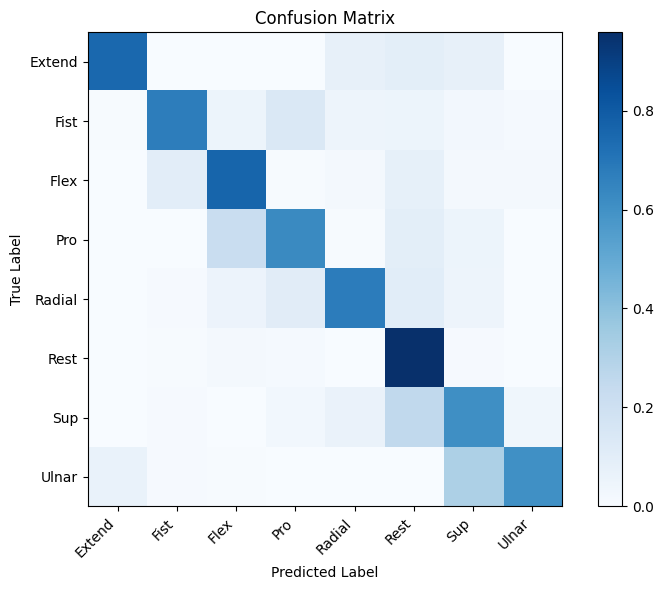

In [112]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

@torch.no_grad()
def evaluate_full(model: nn.Module, dataloader: DataLoader, device):
    """
    Evaluate the model on a full dataloader and return encoded true/pred labels.
    """
    model.eval()

    all_preds = []
    all_labels = []

    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.append(preds)
        all_labels.append(y_batch.numpy())

    return np.concatenate(all_labels), np.concatenate(all_preds)


y_true, y_pred = evaluate_full(model, test_loader, device)

target_names = [inv_label_map[i] for i in range(num_classes)]

print(classification_report(
    y_true,
    y_pred,
    labels=list(range(num_classes)),
    target_names=target_names,
    digits=4,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)), normalize = "true")

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, target_names, rotation=45, ha="right")
plt.yticks(tick_marks, target_names)

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Check Class Imbalance

## Inspect how many samples exist per class in the training set to identify imbalance that could hurt performance.

In [113]:
# Print the distribution of encoded labels in the training set 
print(pd.Series(y_train_encoded).value_counts().sort_index())

0    6028
1    5918
2    6028
3    5758
4    5872
5    6033
6    6137
7    6072
Name: count, dtype: int64


# Plot Training Curves

## Visualize training/validation loss and accuracy across epochs to diagnose overfitting or underfitting.

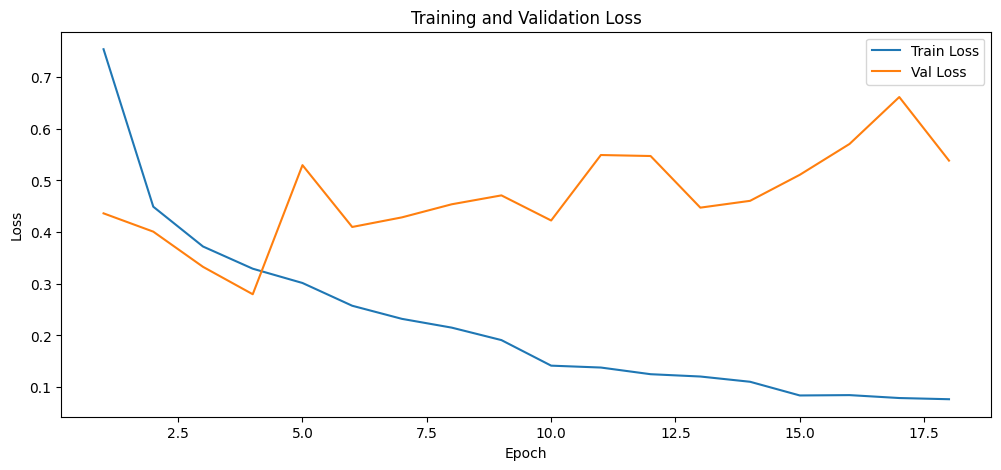

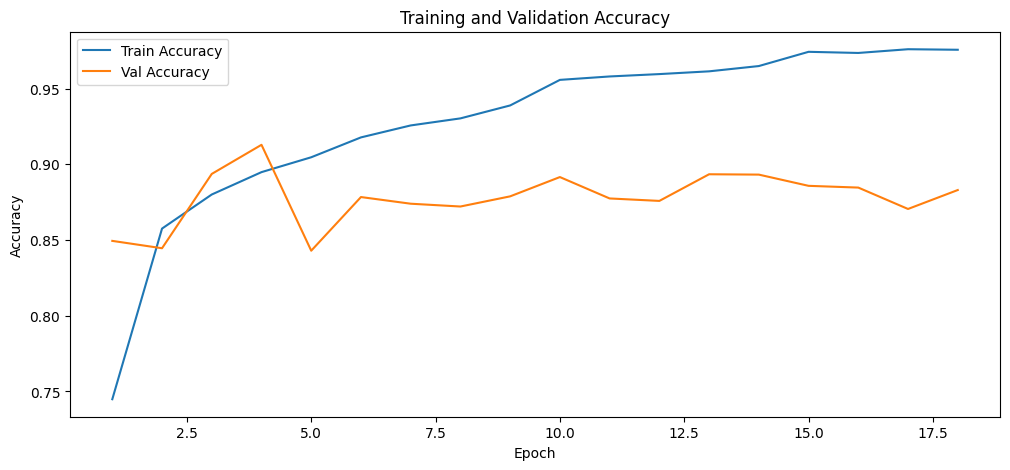

In [114]:
# Convert the training history into a DataFram
hist = pd.DataFrame(history)

# Plot the training and validation loss over epochs
plt.figure(figsize = (12, 5))
plt.plot(hist["epoch"], hist["train_loss"], label = "Train Loss")
if "val_loss" in hist.columns:
    plt.plot(hist["epoch"], hist["val_loss"], label = "Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

# Plot the training and validation accuracy over epochs
plt.figure(figsize = (12, 5))
plt.plot(hist["epoch"], hist["train_accuracy"], label = "Train Accuracy")
if "val_accuracy" in hist.columns:
    plt.plot(hist["epoch"], hist["val_accuracy"], label = "Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.show()

# Save the Model

## Save the trained model and the preprocessing metadata needed to correctly use it later.

In [115]:
out = Path("artifacts")
out.mkdir(exist_ok=True)

torch.save(best_model_state, out / "best_model_v10.pt")

channel_mean, channel_std = mean_std

meta = {
    "window_size": cfg.window_size,
    "step_size": cfg.step_size,
    "sample_rate_hz": cfg.sample_rate_hz,
    "min_segment_seconds": cfg.min_segment_seconds,
    "num_raw_channels": len(channel_cols),
    "num_model_input_features": num_channels,
    "num_classes": num_classes,
    "raw_channel_columns": channel_cols,
    "engineered_feature_names": engineered_feature_names,
    "feature_engineering": {
        "remove_window_dc_offset": True,
        "add_delta_features": True,
    },
    "label_map": label_map,
    "inverted_label_map": {str(k): v for k, v in inv_label_map.items()},
    "raw_spec_label_map": SPEC_LABEL_MAP,
    
    "split_group_name": split_group_name,
    "split_strategy": split_strategy,
    "first_mixed_file_count": FIRST_MIXED_FILE_COUNT,
    "known_subject_block_size": KNOWN_SUBJECT_BLOCK_SIZE,
    "mixed_first_60_subject_id": MIXED_FIRST_60_SUBJECT_ID,
    "known_train_subjects": sorted(list(known_train_subjects)),
    "val_subjects": sorted(list(val_subjects)),
    "test_subjects": sorted(list(test_subjects)),

    # These are required later for live prediction.
    # Live data must be normalized using the training mean/std.
    "channel_mean": channel_mean.tolist(),
    "channel_std": channel_std.tolist(),

    "model_config": {
        "conv_channels": conv_channels,
        "kernel_size": kernel_size,
        "lstm_hidden_size": lstm_hidden_size,
        "lstm_num_layers": lstm_num_layers,
        "dropout": dropout,
        "bidirectional": bidirectional,
    }
}

with open(out / "metadata_v10.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved model and metadata to", out.resolve())

Saved model and metadata to /artifacts
